In [1]:
"""
Extracción de características de regiones segmentadas
Este notebook se centra en la extracción de características cuantitativas de regiones segmentadas.
Una vez segmentada una imagen y etiquetados los objetos individuales, cada región puede describirse mediante propiedades numéricas como el tamaño, la forma, la posición y la intensidad. Estos descriptores son esenciales para el análisis cuantitativo de imágenes y suelen ser el nexo entre el procesamiento de imágenes y el aprendizaje automático.
Objetivos de aprendizaje
- Extraer características geométricas y basadas en la intensidad de regiones etiquetadas
- Crear una tabla de características estructurada a partir de objetos segmentados
- Visualizar la distribución de características
- Explorar las relaciones entre las características extraídas
- Preparar los resultados de la segmentación para flujos de trabajo de aprendizaje automático posteriores
Contexto de la imagen científica
La extracción de características de regiones segmentadas se utiliza ampliamente en la imagen científica para:
- Caracterización de partículas
- Análisis de la morphology de poros
- Cuantificación de defectos
- Estadísticas de microestructura
- Clasificación de objetos
- Aprendizaje automático sobre mediciones derivadas de imágenes
"""

'\nExtracción de características de regiones segmentadas\nEste notebook se centra en la extracción de características cuantitativas de regiones segmentadas.\nUna vez segmentada una imagen y etiquetados los objetos individuales, cada región puede describirse mediante propiedades numéricas como el tamaño, la forma, la posición y la intensidad. Estos descriptores son esenciales para el análisis cuantitativo de imágenes y suelen ser el nexo entre el procesamiento de imágenes y el aprendizaje automático.\nObjetivos de aprendizaje\n- Extraer características geométricas y basadas en la intensidad de regiones etiquetadas\n- Crear una tabla de características estructurada a partir de objetos segmentados\n- Visualizar la distribución de características\n- Explorar las relaciones entre las características extraídas\n- Preparar los resultados de la segmentación para flujos de trabajo de aprendizaje automático posteriores\nContexto de la imagen científica\nLa extracción de características de region

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import filters, morphology, measure, color
from skimage.draw import disk, ellipse

In [3]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def compare_images(images, titles, cmap="gray", figsize=(15, 5), save_path=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def save_dataframe_csv(df, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

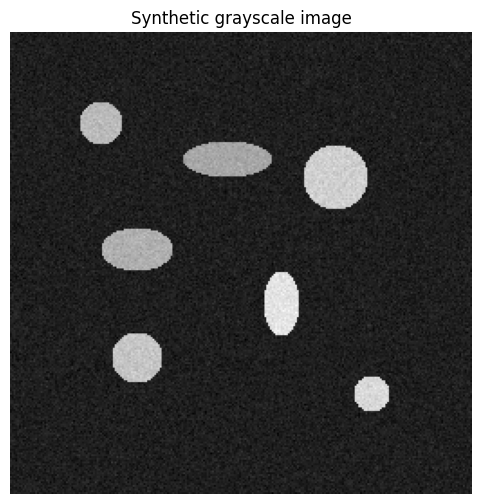

In [6]:
"""
Imagen sintética con objetos segmentados
Comenzamos con una imagen sintética en escala de grises que contiene múltiples objetos con diferentes formas e intensidades.
Esto nos proporciona un ejemplo controlado donde la segmentación es sencilla y las características extraídas se pueden interpretar con claridad.
"""
np.random.seed(42)

image = np.full((256, 256), 30, dtype=np.uint8)

# Circular objects
circles = [
    ((50, 50), 12, 180),
    ((80, 180), 18, 200),
    ((180, 70), 14, 190),
    ((200, 200), 10, 210),
]

for center, radius, intensity in circles:
    rr, cc = disk(center, radius, shape=image.shape)
    image[rr, cc] = intensity

# Elliptical objects
ellipses = [
    (120, 70, 12, 20, 170),
    (150, 150, 18, 10, 220),
    (70, 120, 10, 25, 160),
]

for center_r, center_c, r_radius, c_radius, intensity in ellipses:
    rr, cc = ellipse(center_r, center_c, r_radius, c_radius, shape=image.shape)
    image[rr, cc] = intensity

# Add mild noise
noise = np.random.normal(0, 8, image.shape)
image = np.clip(image + noise, 0, 255).astype(np.uint8)

show_image(
    image,
    "Synthetic grayscale image",
    save_path="../figures/feature_extraction_SR/01_input_image.png"
)

Otsu threshold: 65.00


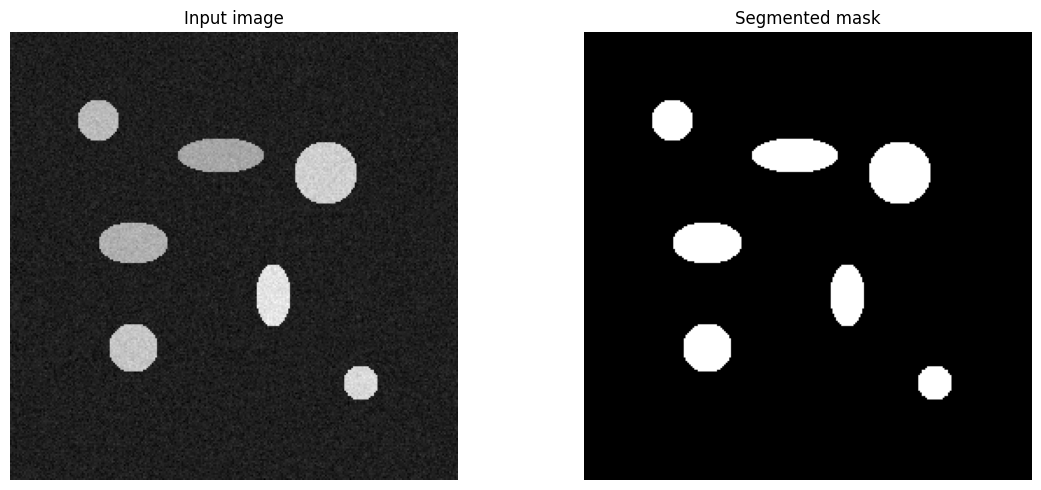

In [7]:
"""
Segmentación de objetos
Segmentamos los objetos brillantes del fondo más oscuro mediante el threshold de Otsu, seguido de una limpieza morphology básica.
"""
threshold = filters.threshold_otsu(image)
mask = image > threshold
mask = morphology.remove_small_objects(mask, max_size=40)
mask = morphology.remove_small_holes(mask, max_size=20)

print(f"Otsu threshold: {threshold:.2f}")

compare_images(
    [image, mask],
    ["Input image", "Segmented mask"],
    figsize=(12, 5),
    save_path="../figures/feature_extraction_SR/02_segmented_mask.png"
)

Number of labeled objects: 7


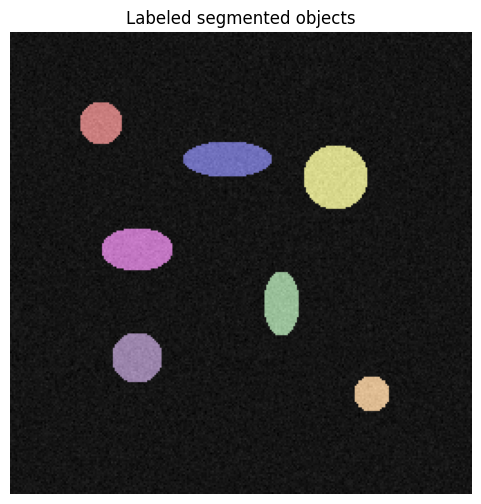

In [8]:
"""
Etiquetado de regiones segmentadas
A cada componente conectado se le asigna una etiqueta única para que los objetos puedan medirse individualmente.
"""
labels = measure.label(mask, connectivity=2)

print(f"Number of labeled objects: {labels.max()}")

show_image(
    color.label2rgb(labels, image=image, bg_label=0),
    "Labeled segmented objects",
    cmap=None,
    save_path="../figures/feature_extraction_SR/03_labeled_objects.png"
)

In [9]:
"""
Extracción de características regionales
Ahora extraemos descriptores cuantitativos de cada región etiquetada.
Las propiedades seleccionadas incluyen:
- Características geométricas: área, perímetro, diámetro equivalente
- Características de forma: excentricidad, solidez
- Características posicionales: centroide
- Información de intensidad: intensidad media
"""
props_table = measure.regionprops_table(
    labels,
    intensity_image=image,
    properties=[
        "label",
        "area",
        "perimeter",
        "equivalent_diameter",
        "eccentricity",
        "solidity",
        "centroid",
        "bbox",
        "mean_intensity"
    ]
)

df_features = pd.DataFrame(props_table)
df_features

,label,area,perimeter,equivalent_diameter,eccentricity,solidity,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3,mean_intensity
0,1,437.0,73.941125,23.588253,0.000000,0.982022,50.0,50.0,39,39,62,62,179.199085
1,2,763.0,115.597980,31.168602,0.918820,0.974457,70.0,120.0,61,96,80,145,160.020970
2,3,1005.0,114.911688,35.771577,0.000000,0.984329,80.0,180.0,63,163,98,198,199.662687
3,4,745.0,103.597980,30.798757,0.805206,0.973856,120.0,70.0,109,51,132,90,169.116779
4,5,553.0,89.941125,26.534910,0.838879,0.978761,150.0,150.0,133,141,168,160,219.663653
5,6,609.0,87.597980,27.846057,0.000000,0.987034,180.0,70.0,167,57,194,84,189.819376
6,7,305.0,62.627417,19.706295,0.000000,0.974441,200.0,200.0,191,191,210,210,209.118033


In [10]:
"""
Agregamos características derivadas
En muchas aplicaciones, resulta útil derivar características interpretables adicionales a partir de las propiedades de la región medidas directamente.
Aquí calculamos:
- Relación de aspecto a partir del cuadro delimitador
- Circularidad a partir del área y el perímetro
"""
bbox_height = df_features["bbox-2"] - df_features["bbox-0"]
bbox_width = df_features["bbox-3"] - df_features["bbox-1"]

df_features["bbox_height"] = bbox_height
df_features["bbox_width"] = bbox_width
df_features["aspect_ratio"] = bbox_width / bbox_height

df_features["circularity"] = (
    4 * np.pi * df_features["area"] / (df_features["perimeter"] ** 2)
)

df_features

,label,area,perimeter,equivalent_diameter,eccentricity,solidity,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3,mean_intensity,bbox_height,bbox_width,aspect_ratio,circularity
0,1,437.0,73.941125,23.588253,0.000000,0.982022,50.0,50.0,39,39,62,62,179.199085,23,23,1.000000,1.004429
1,2,763.0,115.597980,31.168602,0.918820,0.974457,70.0,120.0,61,96,80,145,160.020970,19,49,2.578947,0.717520
2,3,1005.0,114.911688,35.771577,0.000000,0.984329,80.0,180.0,63,163,98,198,199.662687,35,35,1.000000,0.956418
3,4,745.0,103.597980,30.798757,0.805206,0.973856,120.0,70.0,109,51,132,90,169.116779,23,39,1.695652,0.872295
4,5,553.0,89.941125,26.534910,0.838879,0.978761,150.0,150.0,133,141,168,160,219.663653,35,19,0.542857,0.859050
5,6,609.0,87.597980,27.846057,0.000000,0.987034,180.0,70.0,167,57,194,84,189.819376,27,27,1.000000,0.997330
6,7,305.0,62.627417,19.706295,0.000000,0.974441,200.0,200.0,191,191,210,210,209.118033,19,19,1.000000,0.977194


In [11]:
save_dataframe_csv(
    df_features,
    "../figures/feature_extraction_SR/region_features_table.csv"
)

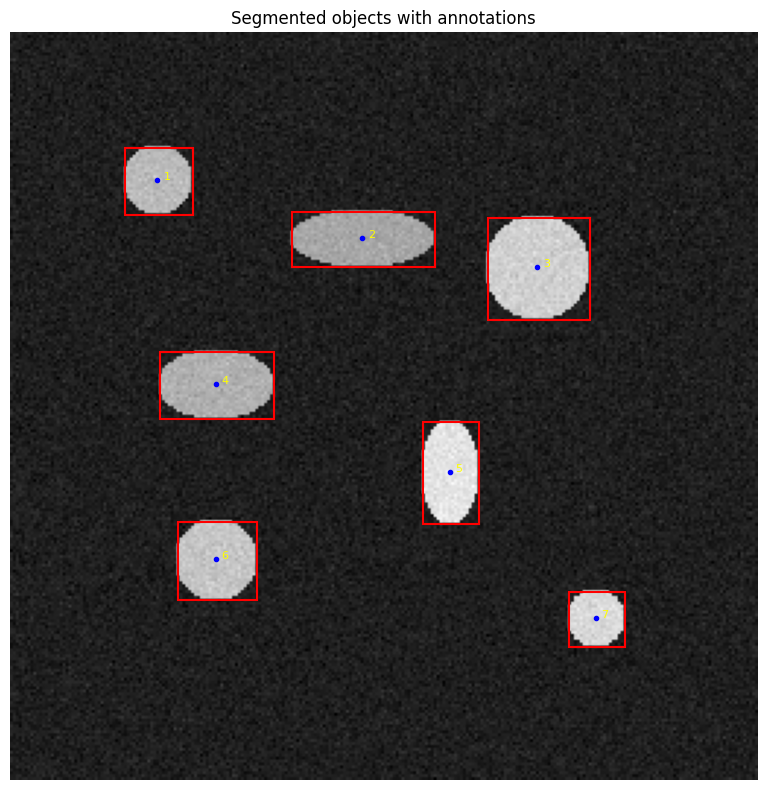

In [12]:
"""
Las características extraídas de la imagen, mostramos cada objeto con su etiqueta, centroide y cuadro delimitador.
"""
regions = measure.regionprops(labels, intensity_image=image)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image, cmap="gray")
ax.set_title("Segmented objects with annotations")
ax.axis("off")

for region in regions:
    minr, minc, maxr, maxc = region.bbox
    y0, x0 = region.centroid

    rect = plt.Rectangle(
        (minc, minr),
        maxc - minc,
        maxr - minr,
        fill=False,
        edgecolor="red",
        linewidth=1.5
    )
    ax.add_patch(rect)
    ax.plot(x0, y0, "bo", markersize=3)
    ax.text(x0 + 2, y0, str(region.label), color="yellow", fontsize=8)

plt.tight_layout()
plt.savefig(
    "../figures/feature_extraction_SR/04_annotated_objects.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

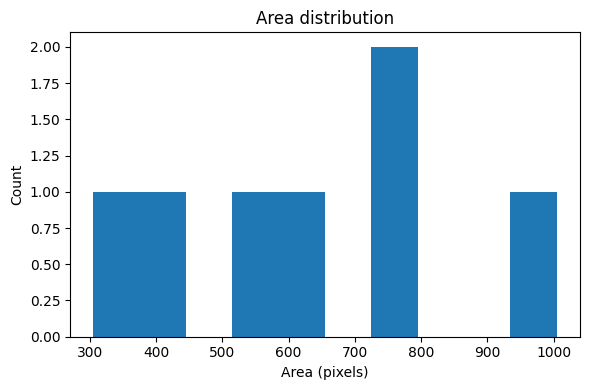

In [13]:
plt.figure(figsize=(6, 4))
plt.hist(df_features["area"], bins=10)
plt.title("Area distribution")
plt.xlabel("Area (pixels)")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(
    "../figures/feature_extraction_SR/05_area_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

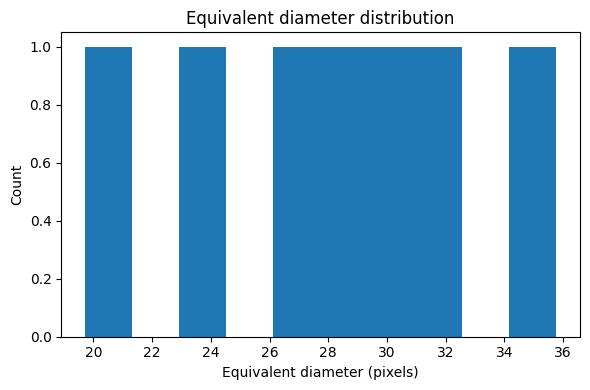

In [14]:
plt.figure(figsize=(6, 4))
plt.hist(df_features["equivalent_diameter"], bins=10)
plt.title("Equivalent diameter distribution")
plt.xlabel("Equivalent diameter (pixels)")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(
    "../figures/feature_extraction_SR/06_equivalent_diameter_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

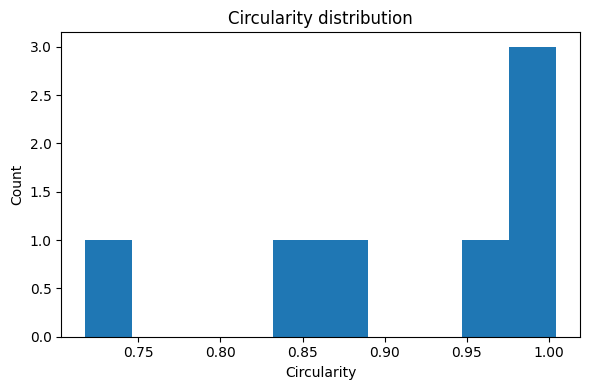

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(df_features["circularity"], bins=10)
plt.title("Circularity distribution")
plt.xlabel("Circularity")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(
    "../figures/feature_extraction_SR/07_circularity_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

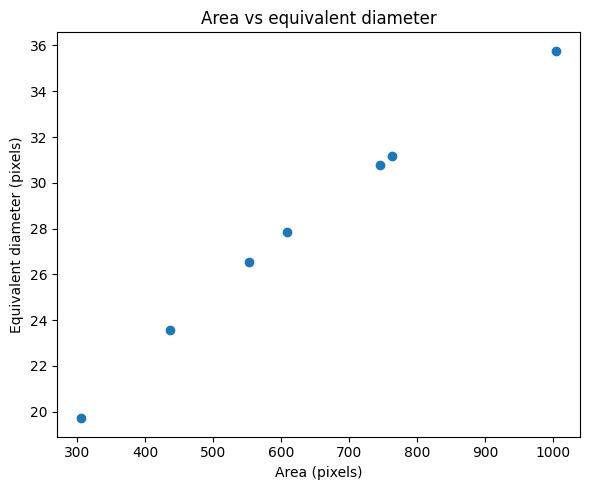

In [18]:
"""
Relaciones entre características
Los diagramas de scattering revelan cómo se relacionan entre sí los descriptores de región.
"""
plt.figure(figsize=(6, 5))
plt.scatter(df_features["area"], df_features["equivalent_diameter"])
plt.title("Area vs equivalent diameter")
plt.xlabel("Area (pixels)")
plt.ylabel("Equivalent diameter (pixels)")
plt.tight_layout()

plt.savefig(
    "../figures/feature_extraction_SR/08_area_vs_equivalent_diameter.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

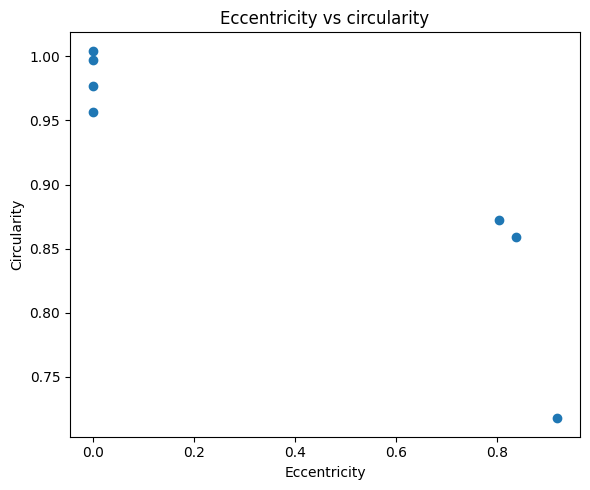

In [19]:
plt.figure(figsize=(6, 5))
plt.scatter(df_features["eccentricity"], df_features["circularity"])
plt.title("Eccentricity vs circularity")
plt.xlabel("Eccentricity")
plt.ylabel("Circularity")
plt.tight_layout()

plt.savefig(
    "../figures/feature_extraction_SR/09_eccentricity_vs_circularity.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [ ]:
"""
Resumen de estadistica de la extraccion de caracteristicas
"""